In [103]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import os
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [129]:
!pip install -q kaggle --upgrade

from google.colab import files
uploaded = files.upload()
!mkdir -p ~/.kaggle
!mv "kaggle (4) (1).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d chest_xray_data
!ls chest_xray_data

Saving kaggle (4).json to kaggle (4) (1).json
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)
replace chest_xray_data/chest_xray/__MACOSX/._chest_xray? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
chest_xray


In [105]:
import os

def get_training_data(sub_dir):

    base_dir = 'chest_xray_data/chest_xray'
    return os.path.join(base_dir, sub_dir)

base_dir = 'chest_xray_data/chest_xray'
train_dir = get_training_data('train')
test_dir = get_training_data('test')
val_dir = get_training_data('val')

In [106]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.8, 1.2]
)

In [107]:
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

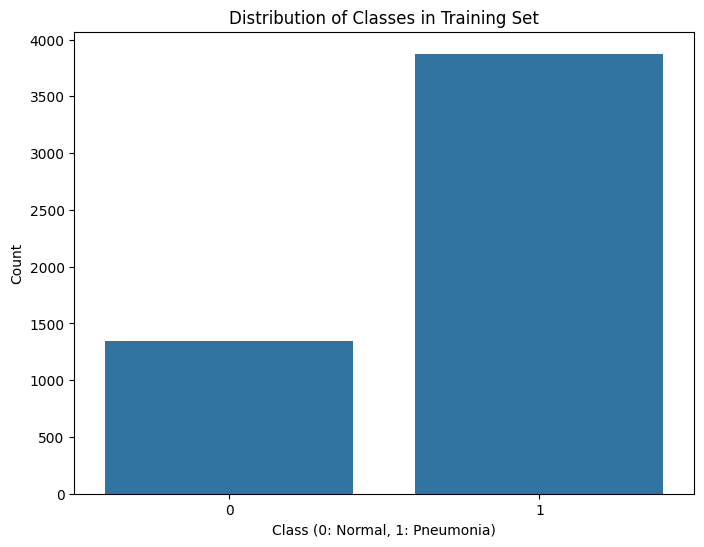

In [108]:
plt.figure(figsize=(8, 6))
sns.countplot(x=train_generator.classes)
plt.title('Distribution of Classes in Training Set')
plt.xlabel('Class (0: Normal, 1: Pneumonia)')
plt.ylabel('Count')
plt.show()

In [109]:
test_generator.reset()
images, labels = next(test_generator)
predictions = model.predict(images)
predicted_classes = np.argmax(predictions, axis=1)
actual_classes = np.argmax(labels, axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step


In [110]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

Found 5216 images belonging to 2 classes.


In [111]:
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Found 16 images belonging to 2 classes.


In [112]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [113]:
labels = train_generator.classes
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
class_weight_dict = dict(enumerate(class_weights * 1.2))  # Modified: Increased class weights by 20% for better balance
print("Class Weights:", class_weight_dict)

Class Weights: {0: np.float64(2.333780760626398), 1: np.float64(0.8076387096774194)}


In [114]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

x = Flatten()(base_model.output)
x = Dense(1024, activation='relu')(x)  #
x = Dropout(0.6)(x)
x = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=x)

In [115]:
model.compile(optimizer=Adam(learning_rate=0.00005), loss='categorical_crossentropy', metrics=['accuracy'])

In [116]:
early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

history = model.fit(train_generator, steps_per_epoch=train_generator.samples // train_generator.batch_size, validation_data=val_generator, validation_steps=val_generator.samples // val_generator.batch_size, epochs=30, class_weight=class_weight_dict, callbacks=[early_stopping])

test_loss, test_accuracy = model.evaluate(test_generator)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 132s 771ms/step - accuracy: 0.7559 - loss: 0.6154 - val_accuracy: 0.8125 - val_loss: 0.3286
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 720ms/step - accuracy: 0.8759 - loss: 0.3586 - val_accuracy: 0.7500 - val_loss: 0.4052
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 145s 740ms/step - accuracy: 0.8836 - loss: 0.3140 - val_accuracy: 0.8750 - val_loss: 0.2650
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 139s 725ms/step - accuracy: 0.8875 - loss: 0.3034 - val_accuracy: 0.9375 - val_loss: 0.2535
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 140s 717ms/step - accuracy: 0.8883 - loss: 0.3024 - val_accuracy: 0.8750 - val_loss: 0.2859
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 143s 720ms/step - accuracy: 0.9025 - loss: 0.2777 - val_accuracy: 0.7500 - val_loss: 0.3626
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 720ms/step - accuracy: 0.9043 - loss: 0.2751 - val_accuracy: 0.8125 - val_loss: 0.2969
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 263ms/step - accuracy: 0.8967 - loss: 0.2201


In [102]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 501ms/step - accuracy: 0.9017 - loss: 0.2198
Test Accuracy: 87.18%


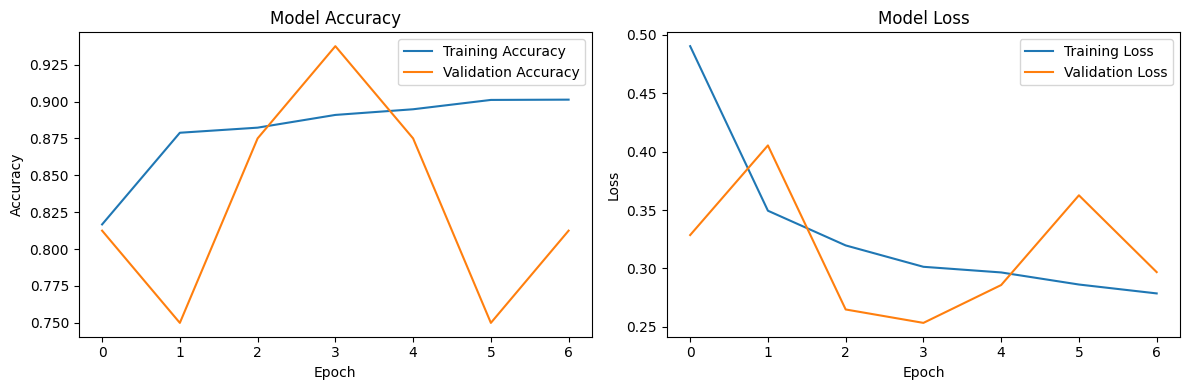

In [117]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [118]:
test_generator.reset()
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
cm = confusion_matrix(true_classes, predicted_classes)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 304ms/step


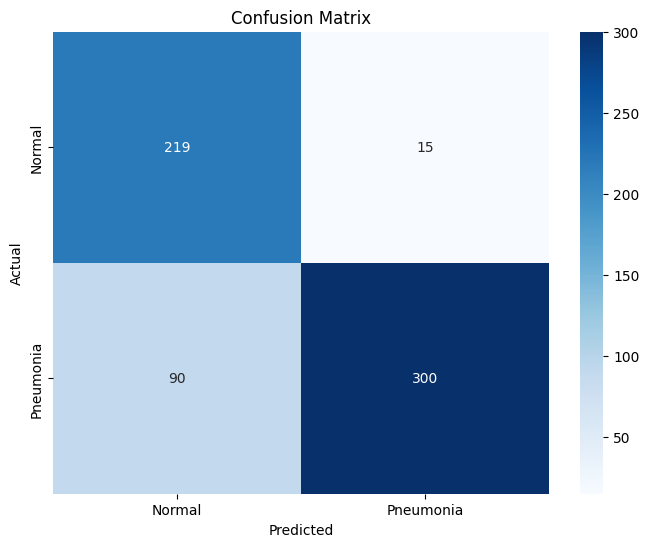

In [119]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [122]:
normal_idx = np.where(actual_classes == 0)[0][0] if len(np.where(actual_classes == 0)[0]) > 0 else 0
pneumonia_idx = np.where(actual_classes == 1)[0][0] if len(np.where(actual_classes == 1)[0]) > 0 else 1

In [123]:
correct = np.where(predicted_classes == true_classes)[0]

In [124]:
test_generator.reset()
all_predictions = []
all_true_classes = []
for i in range(len(test_generator)):
    batch_images, batch_labels = next(test_generator)
    batch_predictions = model.predict(batch_images)
    batch_predicted_classes = np.argmax(batch_predictions, axis=1)
    batch_true_classes = np.argmax(batch_labels, axis=1)
    all_predictions.extend(batch_predicted_classes)
    all_true_classes.extend(batch_true_classes)

all_predictions = np.array(all_predictions)
all_true_classes = np.array(all_true_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step


In [125]:
test_generator.reset()
all_images = []
all_labels = []
for i in range(len(test_generator)):
    imgs, lbls = next(test_generator)
    all_images.append(imgs)
    all_labels.append(lbls)
all_images = np.concatenate(all_images)
all_labels = np.argmax(np.concatenate(all_labels), axis=1)

In [126]:
all_images_grayscale = np.mean(all_images, axis=3)

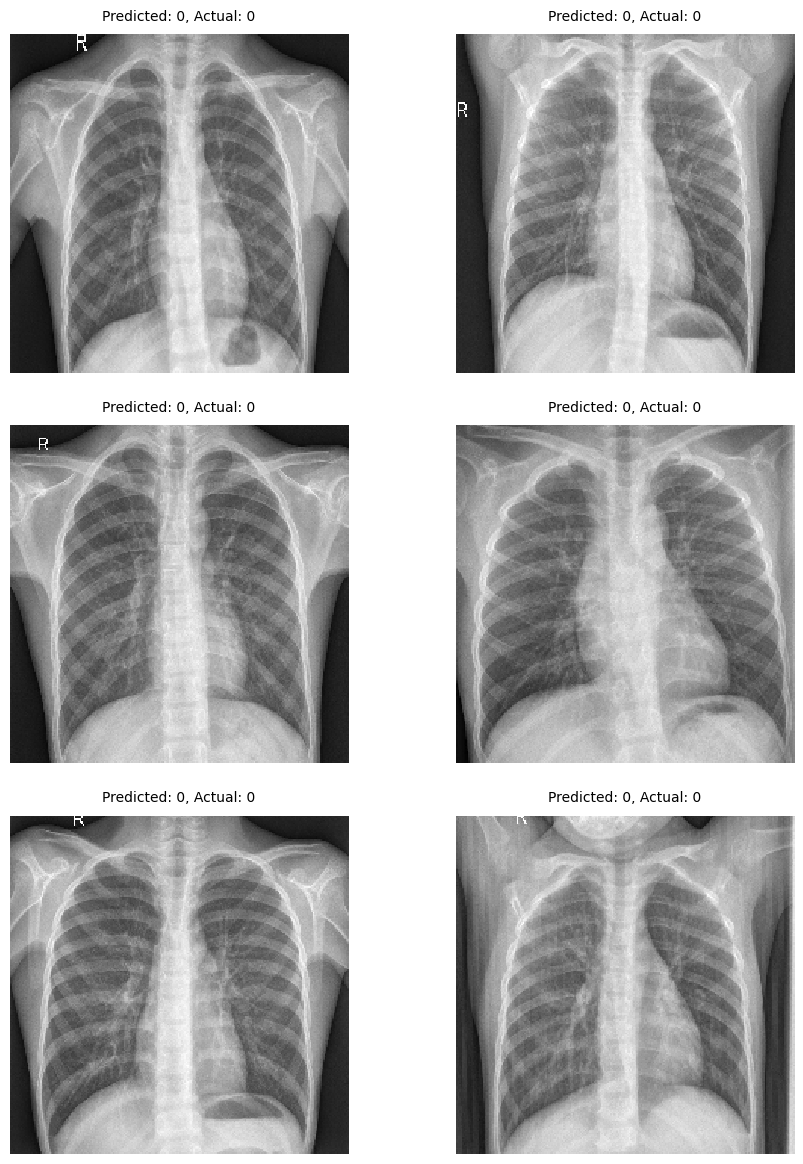

In [127]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes = axes.ravel()
i = 0
for idx in correct[:6]:
    axes[i].imshow(all_images[idx], cmap="gray", interpolation='none')
    axes[i].axis('off')
    axes[i].set_title(f'Predicted: {all_predictions[idx]}, Actual: {all_true_classes[idx]}', fontsize=10, pad=10)
    i += 1
plt.tight_layout(pad=2.0)
plt.savefig('correctly_predicted_images.png')

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

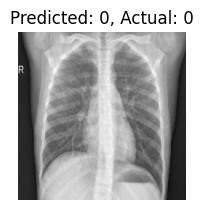

In [131]:
plt.subplot(2, 2, 4)
plt.imshow(all_images[pneumonia_idx], cmap="gray")
plt.title(f'Predicted: {all_predictions[pneumonia_idx]}, Actual: {all_true_classes[pneumonia_idx]}')
plt.axis('off')

In [132]:
model.save("mode.h5")